# FIFA 19 — Graphics

### 1. Carregando o dataset

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [9]:
fifa = pd.read_csv('fifa.csv', index_col=0)
fifa.head()

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,https://cdn.sofifa.org/teams/2/light/241.png,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,https://cdn.sofifa.org/teams/2/light/45.png,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,https://cdn.sofifa.org/teams/2/light/73.png,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,https://cdn.sofifa.org/teams/2/light/11.png,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,https://cdn.sofifa.org/teams/2/light/10.png,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M


In [10]:
fifa.columns

Index(['ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall',
       'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW',
       'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM',
       'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiv

### 2. Gráficos Plot

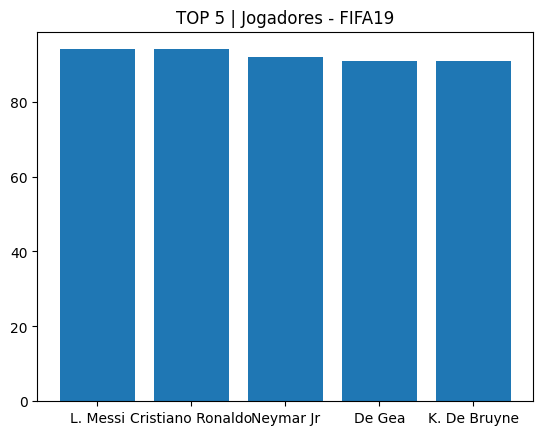

In [11]:
#grafico com objeto DataFrame
graphic1 = fifa[['Name', 'Overall']].head(5)

plt.title('TOP 5 | Jogadores - FIFA19')
plt.bar(graphic1['Name'], graphic1['Overall'])
plt.show()

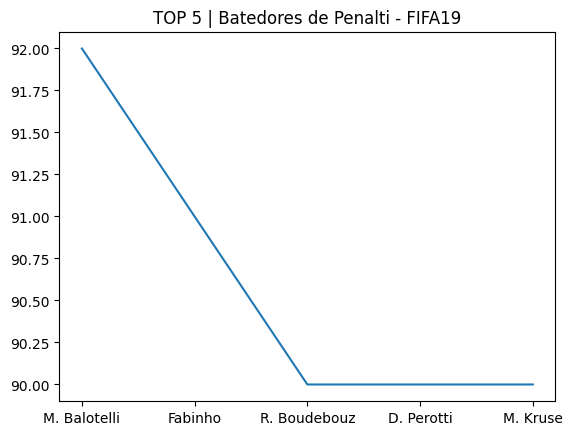

In [12]:
#grafico com objeto Series
graphic2 = fifa.groupby('Name')['Penalties'].mean().sort_values(ascending=False).head(5)

plt.title('TOP 5 | Batedores de Penalti - FIFA19')
plt.plot(graphic2)
plt.show()

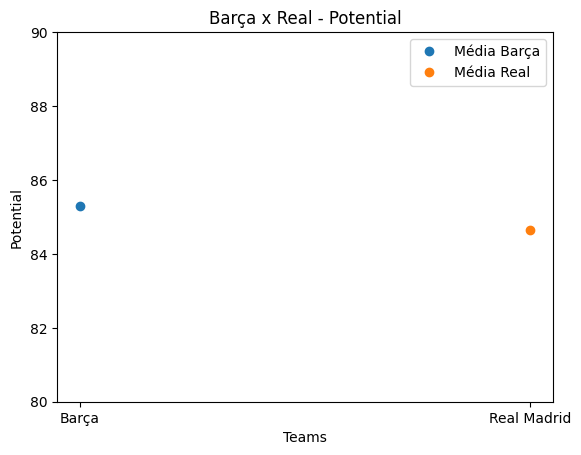

In [13]:
search1 = fifa.loc[fifa['Club'] == 'FC Barcelona']
team1 = search1.groupby('Club')['Potential'].mean(numeric_only=True)

search2 = fifa.loc[fifa['Club'].str.contains('Real Madrid', flags = re.I, na=False)]
team2 = search2.groupby('Club')['Potential'].mean(numeric_only=True)

plt.plot('Barça', team1.values, 'o',label='Média Barça')
plt.plot('Real Madrid', team2.values, 'o', label='Média Real')

plt.title('Barça x Real - Potential')
plt.xlabel('Teams')
plt.ylabel('Potential')
plt.ylim(80, 90) #ajuste de zoom para ver o ponto melhor
plt.legend()
plt.show()

### 3. Gráfico Scatter

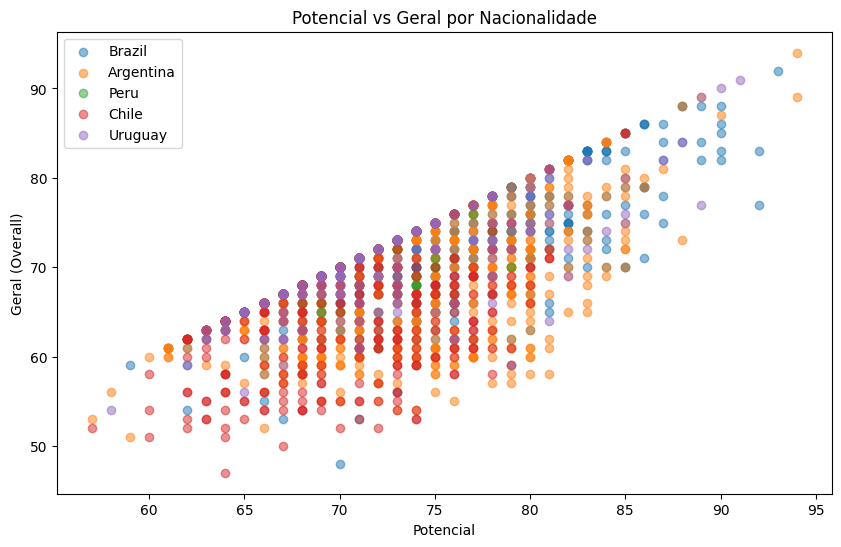

In [14]:
list_natio = ['Brazil', 'Argentina', 'Peru', 'Chile', 'Uruguay']

#configura o tamanho da imagem
plt.figure(figsize=(10, 6))

for natio in list_natio:
    #filtramos o DataFrame para pegar apenas os jogadores daquela nacionalidade
    dados_pais = fifa[fifa['Nationality'] == natio]

    #plotamos o potencial.
    plt.scatter(dados_pais['Potential'], dados_pais['Overall'], label=natio, alpha=0.5)

plt.title('Potencial vs Geral por Nacionalidade')
plt.xlabel('Potencial')
plt.ylabel('Geral (Overall)')
plt.legend() #mostra qual cor pertence a cada país
plt.show()